<a href="https://colab.research.google.com/github/MDRobiulhassan/Machine-Learning-Course/blob/main/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

# Load CIFAR-100 dataset (fine labels by default)
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# Check shapes
print("Training data")
print(f"- X = {x_train.shape}, y = {y_train.shape}")
print(f"- Holds {x_train.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.2f}% of the overall data\n")

print("Testing data")
print(f"- X = {x_test.shape}, y = {y_test.shape}")
print(f"- Holds {x_test.shape[0]/(x_train.shape[0]+x_test.shape[0])*100:.2f}% of the overall data")

Training data
- X = (50000, 32, 32, 3), y = (50000, 1)
- Holds 83.33% of the overall data

Testing data
- X = (10000, 32, 32, 3), y = (10000, 1)
- Holds 16.67% of the overall data


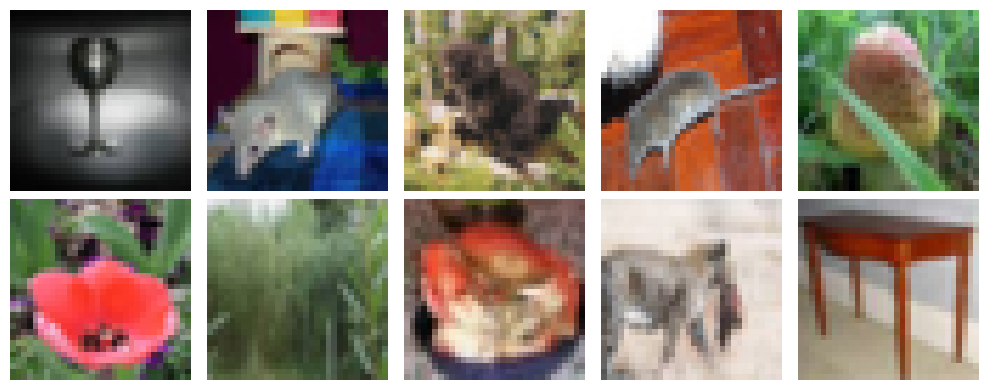

In [52]:
import matplotlib.pyplot as plt
import random

def plot_images(nb_images_to_plot, train_data):
    # Generate a list of random indices from the training data
    random_indices = random.sample(range(len(train_data)), nb_images_to_plot)

    # Compute grid size for plotting
    cols = 5
    rows = (nb_images_to_plot + cols - 1) // cols
    plt.figure(figsize=(cols*2, rows*2))

    # Plot each image using the random indices
    for i, idx in enumerate(random_indices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(train_data[idx])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_images(10, x_train)

In [53]:
import matplotlib.pyplot as plt
import numpy as np

def plot_labels_distribution(data_labels):
    # Flatten if labels are (n,1)
    data_labels = data_labels.flatten() if len(data_labels.shape) > 1 else data_labels

    # Count occurrences of each label
    counts = np.bincount(data_labels, minlength=100)

    # Don't set any style
    # plt.style.use('seaborn-darkgrid')  # removed

    fig, ax = plt.subplots(figsize=(20,5))
    ax.bar(range(100), counts, width=0.8, align='center')
    ax.set(
        xticks=range(0,100,5),
        xlim=[-1, 100],
        xlabel='Class Label',
        ylabel='Count',
        title='Training data label distribution'
    )

    plt.show()

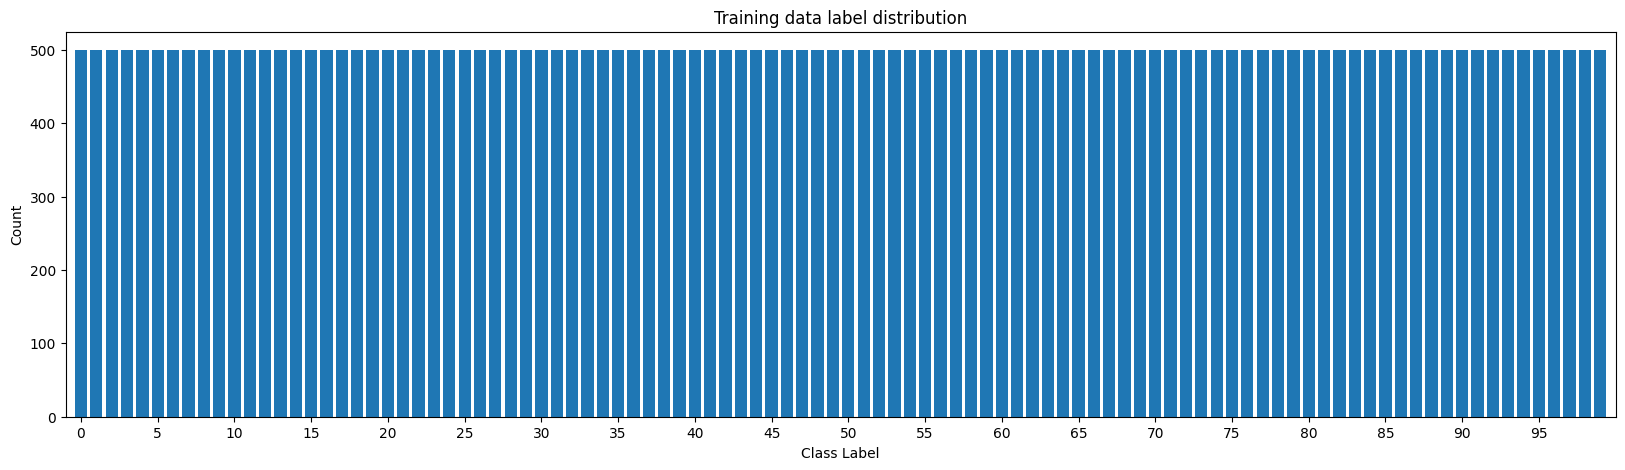

In [54]:
plot_labels_distribution(y_train)